In [1]:
#Importar las librerías:
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode
from IPython.display import display, Image
from langchain.agents import AgentExecutor, create_openai_tools_agent, create_tool_calling_agent
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables.history import RunnableWithMessageHistory
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.messages import HumanMessage

from dotenv import load_dotenv
import os

In [2]:
#Cargar la API KEY
load_dotenv()
api_key = os.getenv("OPENAI_API_KEY")

In [3]:
#Modelo LLM de GPT
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0, openai_api_key=api_key)

In [4]:
#Prueba del modelo con una pregunta
response = llm.invoke("Hola, ¿qué tal tu día?")
response.content

'¡Hola! Estoy aquí y listo para ayudarte. ¿En qué puedo asistirte hoy?'

In [5]:
#Creamos una clase para dictar la estructura de los diccionarios en LangGraph
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [6]:
#Definimos la Tool
#Tools de operaciones básicas
@tool
def add(a: float, b: float) -> str:
    """Suma de dos números."""
    return f"The result of {a} + {b} is {a + b}."

@tool
def subtract(a: float, b: float) -> str:
    """Resta de dos números."""
    return f"The result of {a} - {b} is {a - b}."

@tool
def multiply(a: float, b: float) -> str:
    """Multiplicación de dos números."""
    return f"The result of {a} * {b} is {a * b}."

@tool
def divide(a: float, b: float) -> str:
    """División de dos números."""
    if b == 0:
        return f"Cannot be divided by 0."
    return f"The result of {a} / {b} is {a / b}."

In [7]:
#Lista de tools
tools = [
    add,
    subtract,
    multiply,
    divide
]

In [8]:
#bind_tools une las herramientas al modelo lo que permite invocar las herramientas cuando es necesario.
llm_with_tools = llm.bind_tools(tools)
#invoke se encarga de analizar el texto y aplicar la tool adecuada
response = llm_with_tools.invoke("Wich is the result of add 5 and 7?")
response.content

''

In [9]:
#Creamos el grafo
#call_moodel es un nodo del grafo que representa la invocación del LLM en ese punto del flujo de ejecución.
#Recibe los mensajes, genera la respuesta y lo devuelve al grafo.
def call_model(state: MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [10]:
#Colocamos todas las herramientas en un nodo del grafo, aquí se juntan todas las herramientas las cuales van a ser utilizadas.
tool_node = ToolNode([add, subtract, multiply, divide])

In [11]:
#Ahora vamos a declarar la función del flujo del grafo.
#Aquí se decide si se pasa a las tools o al final.
def next_node(state: MessagesState):
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return 'tools'
    return END

In [12]:
#StateGraph nos permite controlar el flujo a través de nodos, transiciones o condiciones.
builder = StateGraph(MessagesState)

In [13]:
#Ahora vamos a agregarle los nodos al grafo StateGraph
#En este caso añadimos el modelo y el nodo de herramientas
#El metodo recibe el nombre del nodo y la acción (metodo)
builder.add_node('model', call_model)
builder.add_node('tools', tool_node)

In [14]:
#Ahora le damos un "orden" al grafo.
#Le indicamos que siempre va a comenzar en model.
#Luego agregamos la condición en caso de que el prompt sea de otra operación o se finalice el proceso.
#En caso de que sea la tool, se le indica que debe regresar a model
builder.add_edge(START, 'model')
builder.add_conditional_edges('model', next_node, ['tools', END])
builder.add_edge('tools', 'model')

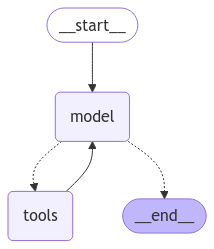

In [15]:
#Ejecutamos y mostramos el grafo
agent = builder.compile()
display(Image(agent.get_graph().draw_mermaid_png()))

In [16]:
#Se invoca el agente con un un prompt
response = agent.invoke(
    input = {'messages': 'Wich is the result of add 5 and 7?'}
)

In [17]:
#Se muestran los mensajes
for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

Wich is the result of add 5 and 7?
================================== Ai Message ==================================
Tool Calls:
  add (call_zIxX8PHV7UiV0ctka586ehFr)
 Call ID: call_zIxX8PHV7UiV0ctka586ehFr
  Args:
    a: 5
    b: 7
================================= Tool Message =================================
Name: add

The result of 5.0 + 7.0 is 12.0.
================================== Ai Message ==================================

The result of adding 5 and 7 is 12.


In [18]:
#Caso 2
response = agent.invoke(
    input = {'messages': 'Wich is the result of multiply 5 and 6?'}
)

In [19]:
#se muestra el resultado del segundo caso
for message in response['messages']:
    message.pretty_print()

================================ Human Message =================================

Wich is the result of multiply 5 and 6?
================================== Ai Message ==================================
Tool Calls:
  multiply (call_YeQJIeXgNbiPs4iI6YvPskDM)
 Call ID: call_YeQJIeXgNbiPs4iI6YvPskDM
  Args:
    a: 5
    b: 6
================================= Tool Message =================================
Name: multiply

The result of 5.0 * 6.0 is 30.0.
================================== Ai Message ==================================

The result of multiplying 5 and 6 is 30.


In [20]:
"""Agent OpenAI"""
prompt = ChatPromptTemplate(
    [
        ('system', 'Eres un agente que puede realizar las siguientes operaciones matemáticas usando herramientas específicas:\n'
                   '- "add" para sumar dos números.\n'
                   '- "subtract" para restar dos números.\n'
                   '- "multiply" para multiplicar dos números.\n'
                   '- "divide" para dividir dos números (ten cuidado, no puedes dividir entre cero).\n'
                   'Cuando respondas, asegúrate de usar la herramienta adecuada.'),
        ('human', '{input}'),
        MessagesPlaceholder(variable_name='agent_scratchpad')
    ]
)

In [21]:
# Crear agente Runnable - Pasos intermedios
agent = create_openai_tools_agent(llm, tools, prompt)

In [22]:
# Agente ejecutor
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

In [23]:
# Ejecutar agente
agent_executor.invoke(
    input={'input': 'Cuanto es 2 + 3?'}
)



> Entering new AgentExecutor chain...

Invoking: `add` with `{'a': 2, 'b': 3}`


The result of 2.0 + 3.0 is 5.0.El resultado de 2 + 3 es 5.

> Finished chain.


{'input': 'Cuanto es 2 + 3?', 'output': 'El resultado de 2 + 3 es 5.'}

In [24]:
# Ejecutar agente
agent_executor.invoke(
    input={'input': 'Cuanto es 9 divido entre 0?'}
)



> Entering new AgentExecutor chain...
No se puede dividir entre cero. La operación no está definida.

> Finished chain.


{'input': 'Cuanto es 9 divido entre 0?',
 'output': 'No se puede dividir entre cero. La operación no está definida.'}

In [25]:
# Agente ejecutor
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

In [26]:
store = {}

In [27]:
# Función ara obtener historial por id
def get_session_history(session_id: str):
    if session_id not in store:
        store[session_id] = InMemoryChatMessageHistory()
    return store[session_id]

In [28]:
# Agente con memoria
agent_memory = RunnableWithMessageHistory(
    agent_executor,
    get_session_history,
    input_messages_key='input',
    history_messages_key='chat_history'
)

In [29]:
# Crear la configuración
config = {'configurable': {'session_id': '100'}}

In [43]:
response = agent_memory.invoke(
    input={'input': 'Cuanto es 5 menos 17?'},
    config=config
)



> Entering new AgentExecutor chain...

Invoking: `subtract` with `{'a': 5, 'b': 17}`


The result of 5.0 - 17.0 is -12.0.5 menos 17 es -12.

> Finished chain.


In [44]:
store

{'100': InMemoryChatMessageHistory(messages=[HumanMessage(content='Cuanto es 5 menos 17?', additional_kwargs={}, response_metadata={}), AIMessage(content='5 menos 17 es -12.', additional_kwargs={}, response_metadata={}), HumanMessage(content='Qué te pregunte hace un momento?', additional_kwargs={}, response_metadata={}), AIMessage(content='No tengo la capacidad de recordar interacciones pasadas. Sin embargo, estoy aquí para ayudarte con cualquier pregunta o tarea que necesites. ¿En qué puedo asistirte hoy?', additional_kwargs={}, response_metadata={}), HumanMessage(content='Qué te pregunte hace un momento?', additional_kwargs={}, response_metadata={}), AIMessage(content='Me preguntaste cuánto es 5 menos 17, y te respondí que es -12. Si tienes más preguntas o necesitas ayuda con algo más, ¡estaré encantado de ayudarte!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 91, 'total_tokens': 131, 'completion_tokens_details': 

In [32]:


response = agent_memory.invoke(
    input={'input': 'Qué te pregunte hace un momento?'},
    config=config
)



> Entering new AgentExecutor chain...
No tengo la capacidad de recordar interacciones pasadas. Sin embargo, estoy aquí para ayudarte con cualquier pregunta o tarea que necesites. ¿En qué puedo asistirte hoy?

> Finished chain.


In [33]:
def get_session_history(session_id: str):
    if session_id not in store:
        store[session_id] = InMemoryChatMessageHistory()
    return store[session_id]

In [34]:
chatbot = RunnableWithMessageHistory(llm, get_session_history)

In [35]:
config = {'configurable': {'session_id': '100'}}

In [45]:
response = chatbot.invoke(
    input=[HumanMessage(content='Qué te pregunte hace un momento?')], # Lista de mensajes
    config=config
)

response.pretty_print()

================================== Ai Message ==================================

Me preguntaste cuánto es 5 menos 17, y te respondí que es -12. Si tienes más preguntas o necesitas ayuda con algo más, ¡estaré encantado de ayudarte!
